# Balance Risk Modeling (EDA + Training)

This notebook builds a Balance Risk classifier using the final processed dataset and saves the trained model for deployment.

In [14]:
# Environment setup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from joblib import dump

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (8, 6)


In [15]:
# Data loading
data_path = Path("..") / "data" / "final_processed_dataset.csv"
df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
display(df.head())
df.info()
display(df.describe().T.head(10))


Dataset shape: (1025, 40)


,pokedex_id,num_types,hp,attack,defense,sp_attack,sp_defense,speed,base_stat_total,height_m,...,type_ghost,type_grass,type_ground,type_ice,type_normal,type_poison,type_psychic,type_rock,type_steel,type_water
0,1,2,-0.946139,-0.958141,-0.803046,-0.171400,-0.195515,-0.772957,318,0.7,...,0,1,0,0,0,1,0,0,0,0
1,2,2,-0.382612,-0.521431,-0.324785,0.334606,0.367837,-0.250367,405,1.0,...,0,1,0,0,0,1,0,0,0,0
2,3,2,0.368758,0.150432,0.358446,1.009281,1.118973,0.446419,525,2.0,...,0,1,0,0,0,1,0,0,0,0
3,4,1,-1.171550,-0.857362,-1.008015,-0.340069,-0.758867,-0.076171,309,0.6,...,0,0,0,0,0,0,0,0,0,0
4,5,1,-0.457749,-0.454244,-0.495592,0.334606,-0.195515,0.446419,405,1.1,...,0,0,0,0,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pokedex_id            1025 non-null   int64  
 1   num_types             1025 non-null   int64  
 2   hp                    1025 non-null   float64
 3   attack                1025 non-null   float64
 4   defense               1025 non-null   float64
 5   sp_attack             1025 non-null   float64
 6   sp_defense            1025 non-null   float64
 7   speed                 1025 non-null   float64
 8   base_stat_total       1025 non-null   int64  
 9   height_m              1025 non-null   float64
 10  weight_kg             1025 non-null   float64
 11  base_experience       1025 non-null   int64  
 12  capture_rate          1025 non-null   int64  
 13  base_happiness        1025 non-null   int64  
 14  hatch_counter         1025 non-null   int64  
 15  gender_rate          

,count,mean,std,min,25%,50%,75%,max
pokedex_id,1025.0,5.130000e+02,296.036315,1.000000,257.000000,513.000000,769.000000,1025.000000
num_types,1025.0,1.513171e+00,0.500070,1.000000,1.000000,2.000000,2.000000,2.000000
hp,1025.0,-9.011762e-17,1.000488,-2.599152,-0.758297,-0.082064,0.556600,6.943241
attack,1025.0,1.940995e-16,1.000488,-2.436238,-0.756582,-0.084720,0.755108,3.476149
defense,1025.0,2.356922e-16,1.000488,-2.306154,-0.768885,-0.085654,0.597577,5.380193
sp_attack,1025.0,8.318549e-17,1.000488,-2.026756,-0.778608,-0.171400,0.671943,3.471844
sp_defense,1025.0,1.421085e-16,1.000488,-1.885572,-0.758867,-0.120402,0.593178,6.001358
speed,1025.0,-5.892306e-17,1.000488,-2.166529,-0.772957,-0.076171,0.725133,4.627135
base_stat_total,1025.0,4.276868e+02,112.770735,175.000000,325.000000,450.000000,508.000000,720.000000
height_m,1025.0,1.211610e+00,1.248167,0.100000,0.500000,1.000000,1.500000,20.000000


In [16]:
# Target labeling: statistical proxy for "Broken" Pokemon
offensive_cutoff = df["offensive_total"].quantile(0.90)
df["is_balance_risk"] = (
    (df["base_stat_total"] > 590) | (df["offensive_total"] >= offensive_cutoff)
).astype(int)

df["is_balance_risk"].value_counts(normalize=True).rename("proportion")


is_balance_risk
0    0.88
1    0.12
Name: proportion, dtype: float64

In [17]:
# Feature selection
#X = df.drop(columns=["pokedex_id", "is_balance_risk"])
# In the Feature Selection cell, drop the columns used to create the label
X = df.drop(columns=["pokedex_id", "is_balance_risk", "base_stat_total", "offensive_total"])
y = df["is_balance_risk"]

print("Features:", X.shape[1])
X.head()


Features: 37


,num_types,hp,attack,defense,sp_attack,sp_defense,speed,height_m,weight_kg,base_experience,...,type_ghost,type_grass,type_ground,type_ice,type_normal,type_poison,type_psychic,type_rock,type_steel,type_water
0,2,-0.946139,-0.958141,-0.803046,-0.171400,-0.195515,-0.772957,0.7,6.9,64,...,0,1,0,0,0,1,0,0,0,0
1,2,-0.382612,-0.521431,-0.324785,0.334606,0.367837,-0.250367,1.0,13.0,142,...,0,1,0,0,0,1,0,0,0,0
2,2,0.368758,0.150432,0.358446,1.009281,1.118973,0.446419,2.0,100.0,236,...,0,1,0,0,0,1,0,0,0,0
3,1,-1.171550,-0.857362,-1.008015,-0.340069,-0.758867,-0.076171,0.6,8.5,62,...,0,0,0,0,0,0,0,0,0,0
4,1,-0.457749,-0.454244,-0.495592,0.334606,-0.195515,0.446419,1.1,19.0,142,...,0,0,0,0,0,0,0,0,0,0


In [18]:
# Model fitting (Random Forest)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


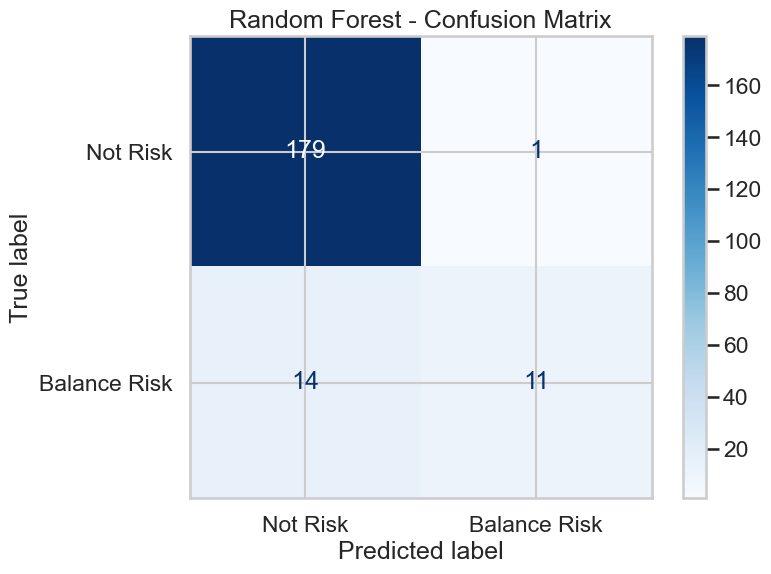

              precision    recall  f1-score   support

    Not Risk       0.93      0.99      0.96       180
Balance Risk       0.92      0.44      0.59        25

    accuracy                           0.93       205
   macro avg       0.92      0.72      0.78       205
weighted avg       0.93      0.93      0.92       205



In [19]:
# Model evaluation
y_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Risk", "Balance Risk"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest - Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=["Not Risk", "Balance Risk"]))


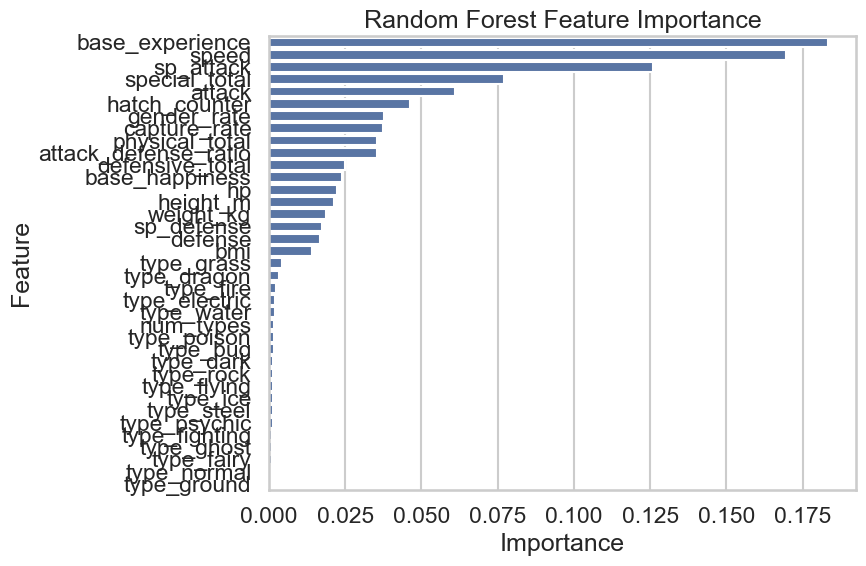

base_experience         0.183303
speed                   0.169604
sp_attack               0.125906
special_total           0.077191
attack                  0.060882
hatch_counter           0.046415
gender_rate             0.037868
capture_rate            0.037484
physical_total          0.035505
attack_defense_ratio    0.035329
dtype: float64

In [20]:
# Feature importance visualization
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, color="#4C72B0")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importances.head(10)


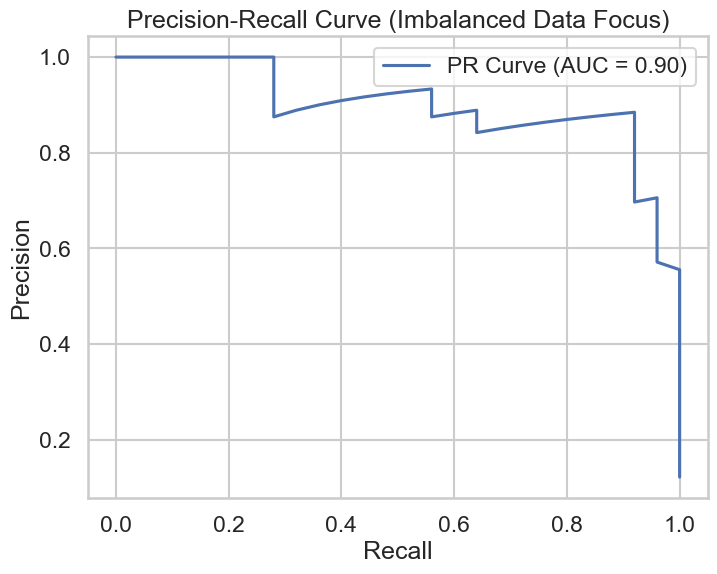

In [23]:
from sklearn.metrics import precision_recall_curve, auc

# Get probabilities
y_probs = rf_model.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Imbalanced Data Focus)')
plt.legend()
plt.show()

In [21]:
# Baseline model for comparison: Logistic Regression
log_reg_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
)
log_reg_model.fit(X_train, y_train)

log_reg_pred = log_reg_model.predict(X_test)
print("Logistic Regression Baseline")
print(classification_report(y_test, log_reg_pred, target_names=["Not Risk", "Balance Risk"]))


Logistic Regression Baseline
              precision    recall  f1-score   support

    Not Risk       1.00      0.95      0.97       180
Balance Risk       0.74      1.00      0.85        25

    accuracy                           0.96       205
   macro avg       0.87      0.97      0.91       205
weighted avg       0.97      0.96      0.96       205



In [22]:
# Export trained Random Forest model
models_dir = Path("..") / "models"
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "balance_risk_random_forest.joblib"
dump(rf_model, model_path)
model_path


WindowsPath('../models/balance_risk_random_forest.joblib')